In [1]:
import math
import csv
import numpy as np
import matplotlib.pyplot as plt
from math import e
import statistics as st
import cmath
import scipy
import scipy.stats as ss
import random
import seaborn as sns
import pandas as pd
import pyswarms
import emcee
import corner

In [11]:
data = map(lambda x: [ x[0], x[1], x[2] ],
        np.loadtxt("/Users/gopipatel/Documents/RRI_VSP/saras3_S11_200mm_above_water.s1p", skiprows=5))

d=list(data) #List of the format [Frequency, Magnitude, Phase (in degrees)]
c=3*10**8  # speed of light (m/s)
freq=[d[i][0] for i in range(len(d))] #frequency

In [12]:
def Compute_Tmeas_(PA, gamma_A, PN, gamma_N, f, l): 
    A=0
    B=0
    C=0
    l=l
    itr=3
    Tmeas=[]
    phi_A=0
    phi_N=0
    phi_f=0
    P_ref=300
    
    l=l
    freq= [d[i][0] for i in range(len(d))]
    for i in range(len(freq)):
        
        phi= (4*math.pi*(freq[i])*l)/(0.7*c)
        A=sum((abs(gamma_A)**k)*(abs(gamma_N)**k)*sum(math.cos((2*l-k)*(phi_N+phi_A+phi))for l in range(k+1)) for k in range(itr))   
        
        B=sum(2*abs(f)*(abs(gamma_A)**(o+1))*(abs(gamma_N)**o)*math.cos(phi_f+(o+1)*(phi_A+phi)+o*phi_N) for o in range(itr))
    
        C=sum((abs(gamma_A)**b)*(abs(gamma_N)**b)*sum(math.cos((2*c-b)*(phi_N+phi_A+phi)) for c in range(b+1)) for b in range(itr))
        
        Tmeas.append((PA*A-P_ref)+PN*(B+(abs(f)**2)*(abs(gamma_A)**2)*C))
    return(Tmeas)

In [40]:
def Compute_Tmeas_RLC(PA, p0, p1, p2, p3, p4, p5, p6, PN, gamma_N, f, l): 
    A=0
    B=0
    C=0
    l=l
    itr=3
    Tmeas=[]
    phi_A=0
    phi_N=0
    phi_f=0
    P_ref=300
    c=3*1e8
    l=l
    N=7
    freq= [d[i][0] for i in range(len(d))]
    for i in range(len(freq)):
        gamma_A=p0*1e-48* freq[i] ** (N - 1) + p1*1e-39* freq[i] ** (N - 2) + p2*1e-31* freq[i] ** (N - 3) + p3*1e-23* freq[i] ** (N - 4) + p4*1e-15* freq[i] ** (N - 5) + p5*1e-08* freq[i] ** (N - 6) + p6*1e-01
        
        phi= (4*math.pi*(freq[i])*l)/(0.7*c)
        A=sum((abs(gamma_A)**k)*(abs(gamma_N)**k)*sum(math.cos((2*l-k)*(phi_N+phi_A+phi))for l in range(k+1)) for k in range(itr))   
        
        B=sum(2*abs(f)*(abs(gamma_A)**(o+1))*(abs(gamma_N)**o)*math.cos(phi_f+(o+1)*(phi_A+phi)+o*phi_N) for o in range(itr))
    
        C=sum((abs(gamma_A)**b)*(abs(gamma_N)**b)*sum(math.cos((2*c-b)*(phi_N+phi_A+phi)) for c in range(b+1)) for b in range(itr))
        
        Tmeas.append((PA*A-P_ref)+PN*(B+(abs(f)**2)*(abs(gamma_A)**2)*C))
    return(Tmeas)

# MCMC for Open

In [46]:
########## Define the log-likelihood function
def log_likelihood(ip_params, params):
    PA, gamma_A, PN, gamma_N, f, l = params
    
    # Define the Expected TA values
    TA_exp = Compute_Tmeas_(*ip_params) + np.random.normal(0,0.001,len(freq))  # Expected TA values
    TA_exp=np.array(TA_exp)
    
    # Compute model TA
    TA_model = Compute_Tmeas_(PA, gamma_A, PN, gamma_N, f,  l)
    TA_model=np.array(TA_model)

    # Compute chi-squared with weights
    s = 0.001  # Uncertainty
    chi2 = np.sum([((TA_exp - TA_model)/s)** 2 ]) 

    return -0.5*chi2 - np.log(math.sqrt(2*np.pi)*s) #+ np.log(s**2) # Likelihood function

########## Define the log-prior function
def log_prior(params):
    
    PA, gamma_A, PN, gamma_N, f, l = params
    """
    # Check if params are within bounds
    if 0.0 < PA < 5 and 0.0 < gamma_A < 1.0 and 5.0 < PN < 100.0 and 0.0 < gamma_N < 1.0 and 0.05 < f < 0.9 and 0.1 < l < 1.0:
        return 0.0
    return -np.inf
    
    for p, min_v, max_v in zip(params, min_values, max_values):
        if not (min_v <= p <= max_v):
            return -np.inf  # Reject sample
    """
    return 0.0  # Uniform prior

######### Define the full log-probability function

def log_probability(ip_params,params):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(ip_params,params)

########### MCMC

def evolve_MCMC_o(ip_params, type, nsteps, initial_value):# Define parameter names
    parameter_names = ["PA", "gamma_A", "PN", "gamma_N", "f","l"]

    # Define bounds for parameters
    """
    min_values = [0.0, 0.0, 50.0, 0.0, 0.05,0.05]
    if type=='open' or type=='short':
        max_values= [5, 1, 150, 1,0.5, 13] 
    else:
        max_values = [350, 1, 150, 1, 0.5, 13] #maximum value of mass being scanned for load terminal
    """
    

    # Number of walkers and steps
    ndim = 6  # Number of parameters
    nwalkers = 150  # Number of MCMC walkers
    nsteps = nsteps  # Number of MCMC steps per walker
    
    # Initialize walkers around a random point in parameter space
    initial_value= np.array(initial_value)
    
    ## Starting positions for the walkers
    pos= initial_value[None,:] + initial_value*1e-1*np.random.randn(nwalkers, ndim) #initial_exact[None,:]*

    #Make sure all the positions are positive
    for idim in range(ndim):
        ind_pos = pos[:,idim]<0
        pos[ind_pos,idim] = np.abs(pos[ind_pos,idim])
    
    #pos= initial_exact+ 1e-1*np.array([[np.random.uniform(min_v, max_v) for min_v, max_v in zip(min_values, max_values)] for _ in range(nwalkers)]) 

    def wrap_log_probability(params):
        return log_probability(ip_params, params)
        
    ############ Set up the MCMC sampler
    sampler = emcee.EnsembleSampler(nwalkers, ndim, wrap_log_probability, threads=10)
    
    ############ Run MCMC
    print("Running MCMC...")
    sampler.run_mcmc(pos, nsteps, progress=True)
    
    ############ Extract the samples
    #samples = sampler.flatchain
    full_samples=sampler.get_chain()
    samples = sampler.get_chain(discard=500, flat=True)

    ######### Compute log-likelihoods for all samples
    log_likes = np.array([log_likelihood(ip_params, p) for p in samples])
    
    ######### Find the index of the maximum likelihood
    max_likelihood_index = np.argmax(log_likes)
    
    ########## Get the best-fit parameters
    best_fit_params = samples[max_likelihood_index].tolist()

    return full_samples,samples,best_fit_params

In [47]:
#evolve MCMC
ip_params=[0,1,70,0.312,0.1,1] #input parameters
nsteps=3000
#initials=[325,0.01,69.3,0.3,0.099,9.5]
initials=[0.2,0.92,60,0.3,0.1,0.75]
full_samples_o, samples_o, best_fit_params_o= evolve_MCMC_o(ip_params,type='open',nsteps=nsteps, initial_value=initials)

Running MCMC...


100%|███████████████████████████████████████| 3000/3000 [08:41<00:00,  5.75it/s]


2025-04-23 11:40:55,328 - root - WARNING - Too few points to create valid contours
2025-04-23 11:40:55,403 - root - WARNING - Too few points to create valid contours
2025-04-23 11:40:55,451 - root - WARNING - Too few points to create valid contours
2025-04-23 11:40:55,523 - root - WARNING - Too few points to create valid contours
2025-04-23 11:40:55,571 - root - WARNING - Too few points to create valid contours
2025-04-23 11:40:55,614 - root - WARNING - Too few points to create valid contours
2025-04-23 11:40:55,684 - root - WARNING - Too few points to create valid contours
2025-04-23 11:40:55,733 - root - WARNING - Too few points to create valid contours
2025-04-23 11:40:55,778 - root - WARNING - Too few points to create valid contours
2025-04-23 11:40:55,823 - root - WARNING - Too few points to create valid contours
2025-04-23 11:40:55,892 - root - WARNING - Too few points to create valid contours
2025-04-23 11:40:55,937 - root - WARNING - Too few points to create valid contours
2025

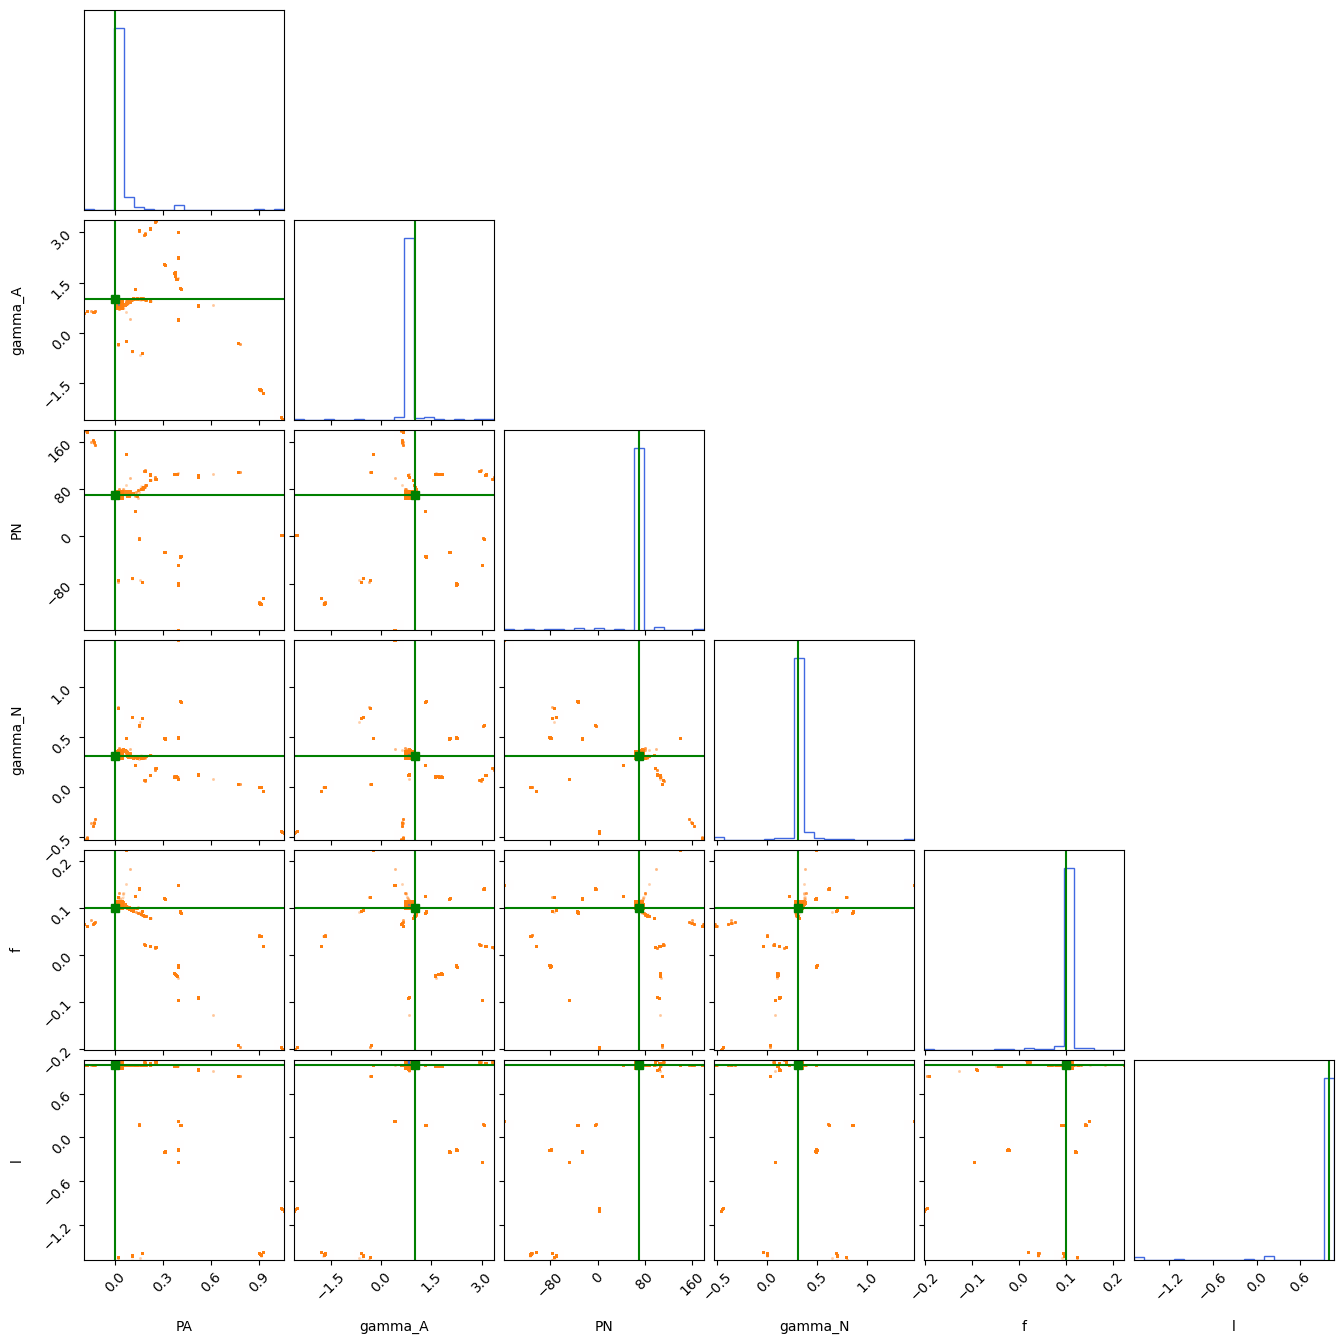

Best-fit parameters (Maximum Likelihood Estimate): [0.056994013257963286, 0.8438366477785124, 76.25344810716076, 0.36978580247553566, 0.10878953732937753, 1.0000069828574822]


In [49]:
parameter_names = ["PA", "gamma_A", "PN", "gamma_N", "f","l"]
#corner plot 
fig = corner.corner(samples, labels=parameter_names, truths=ip_params, color='C1',  # Change color of the contour and histograms
hist_kwargs={"color": "royalblue"},  # Set histogram color
contour_kwargs={"colors": ["royalblue"]},  # Set contour color
truth_color="green" ) # Color for the true parameter values)
#plt.savefig('/Users/gopipatel/Desktop/MCMC_load.png', dpi=300)
plt.show()

#print("Expected Paramerters:",ip_params)
print("Best-fit parameters (Maximum Likelihood Estimate):", best_fit_params_o)

## MCMC for RLC coeffs with fixed params from open

In [52]:
########## Define the log-likelihood function
def log_likelihood(ip_params,params,**kwargs):

    #PA = kwargs["PA"]
    PN = kwargs["PN"]
    gamma_N = kwargs["gamma_N"]
    f = kwargs["f"]
    l = kwargs["l"]
    #ip_params = args["ip_params"]
    s = kwargs["s"]

    #print(PA,ip_params)

    # Compute TA expected
    
    PA, p0, p1, p2, p3, p4, p5, p6 = ip_params
    
    np.random.seed(3)
    TA_exp = Compute_Tmeas_RLC(PA, p0, p1, p2, p3, p4, p5, p6, PN, gamma_N, f, l) + np.random.normal(0,0.001,len(freq))  # Expected TA values
    TA_exp=np.array(TA_exp)
    
    # Compute model TA

    PA, p0, p1, p2, p3, p4, p5, p6 = params
    TA_model = Compute_Tmeas_RLC(PA, p0, p1, p2, p3, p4, p5, p6, PN, gamma_N, f, l) 
    TA_model=np.array(TA_model)

    # Compute chi-squared
    chi2 = np.sum([((TA_exp - TA_model)/s)** 2 ]) 

    return -0.5*chi2 - np.log(math.sqrt(2*np.pi)*s)

########## Define the log-prior function
def log_prior(params):

    ## Define bounds for parameters
    #min_values = [ -6,  1, -5,  3.8, -2.5,  4.5,  4]
    #if type=='open' or type=='short':
    #max_values= [-5,  3, -4,  4.8, -1.8,  5.5,  5] 
    
    PA, p0, p1, p2, p3, p4, p5, p6 = params
    """
    N=7
    gamma_rlc=[]
    for i in range(len(v)):
        
        gamma_value = (p0 * v[i] ** (N - 1) + 
                   p1 * v[i] ** (N - 2) + 
                   p2 * v[i] ** (N - 3) + 
                   p3 * v[i] ** (N - 4) + 
                   p4 * v[i] ** (N - 5) + 
                   p5 * v[i] ** (N - 6) + 
                   p6)
        if not (-1 <= gamma_value <= 1):
            return -np.inf  # Reject sample
        
        gamma_rlc.append(gamma_value)
        
    
    
    #for p, min_v, max_v in zip(params, min_values, max_values):
        #if not (min_v <= p <= max_v):
            #return -np.inf  # Reject sample
    """
    return 0.0  # Uniform prior
    
######### Define the full log-probability function
    
def log_probability(ip_params,params,**kwargs):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(ip_params,params,**kwargs)


########## MCMC for RLC Coeffs.
def evolve_MCMC_RLC(ip_params,nsteps, initial_value,**kwargs):
    
    # Define parameter names
    parameter_names = ["PA", "p0", "p1", "p2", "p3", "p4", "p5", "p6", "PN", "gamma_N", "f", "l"]

    ## Number of walkers and steps
    
    ndim = 8  # Number of parameters
    nwalkers = 200  # Number of MCMC walkers
    nsteps = nsteps  # Number of MCMC steps per walker
    
    ## Initialize walkers around a random point in parameter space
    
    initial_value=initial_value

    ## Starting positions for the walkers
    
    pos= initial_value + 1e-1*np.random.randn(nwalkers, ndim) #initial_exact[None,:]*
    
    """
    ## for making sure only positive positional values
    for idim in range(ndim):
        ind_pos = pos[:,idim]<0
        pos[ind_pos,idim] = np.abs(pos[ind_pos,idim])
    """ 
    def wrap_log_probability(params):
        return log_probability(ip_params, params, **kwargs)
    
    ## Set up the MCMC sampler
    
    sampler = emcee.EnsembleSampler(nwalkers, ndim, wrap_log_probability, threads=10)
    
    ## Run MCMC
    
    print("Running MCMC...")
    sampler.run_mcmc(pos, nsteps, progress=True)
    
    ## Extract the samples
    
    full_samples=sampler.get_chain()
    samples = sampler.get_chain(discard=500, flat=True)

    ## Compute log-likelihoods for all samples
    
    log_likes = np.array([log_likelihood(ip_params,p,**kwargs) for p in samples])
    
    ## Find the index of the maximum likelihood
    
    max_likelihood_index = np.argmax(log_likes)
    
    ## Get the best-fit parameters
    
    best_fit_params = samples[max_likelihood_index].tolist()

    return full_samples,samples,best_fit_params

In [69]:
PA=300
s=0.01
PA_o, gamma_Ao, PN, gamma_N, f, l=best_fit_params_o
kwargs={"PN":PN,  "gamma_N":gamma_N, "f":f, "l":l, "s":s}
ip_params=[300, -6.33,  2.67, -4.56,  4.17, -2.186,  5.07,  4.73]
initials=[301, -6,  2.4, -4.1,  4.0, -1.96,  4.7,  4.5]

full_samples_rlc, samples_rlc, best_fit_params_rlc= evolve_MCMC_RLC(ip_params=ip_params, nsteps=nsteps, initial_value=initials, **kwargs)

Running MCMC...
emcee: Exception while calling your likelihood function:
  params: [301.17508467  -6.00721434   2.49924676  -4.08175527   4.06742149
  -1.92061185   4.63772128   4.53663243]
  args: []
  kwargs: {}
  exception:


Traceback (most recent call last):
  File "/Users/gopipatel/my_env/lib/python3.10/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
  File "/var/folders/zm/pwt73btx1vzfr8smfkhs78c00000gn/T/ipykernel_3918/3391846895.py", line 103, in wrap_log_probability
    return log_probability(ip_params, params, **kwargs)
TypeError: log_probability() got an unexpected keyword argument 'PN'


TypeError: log_probability() got an unexpected keyword argument 'PN'

IndexError: list index out of range

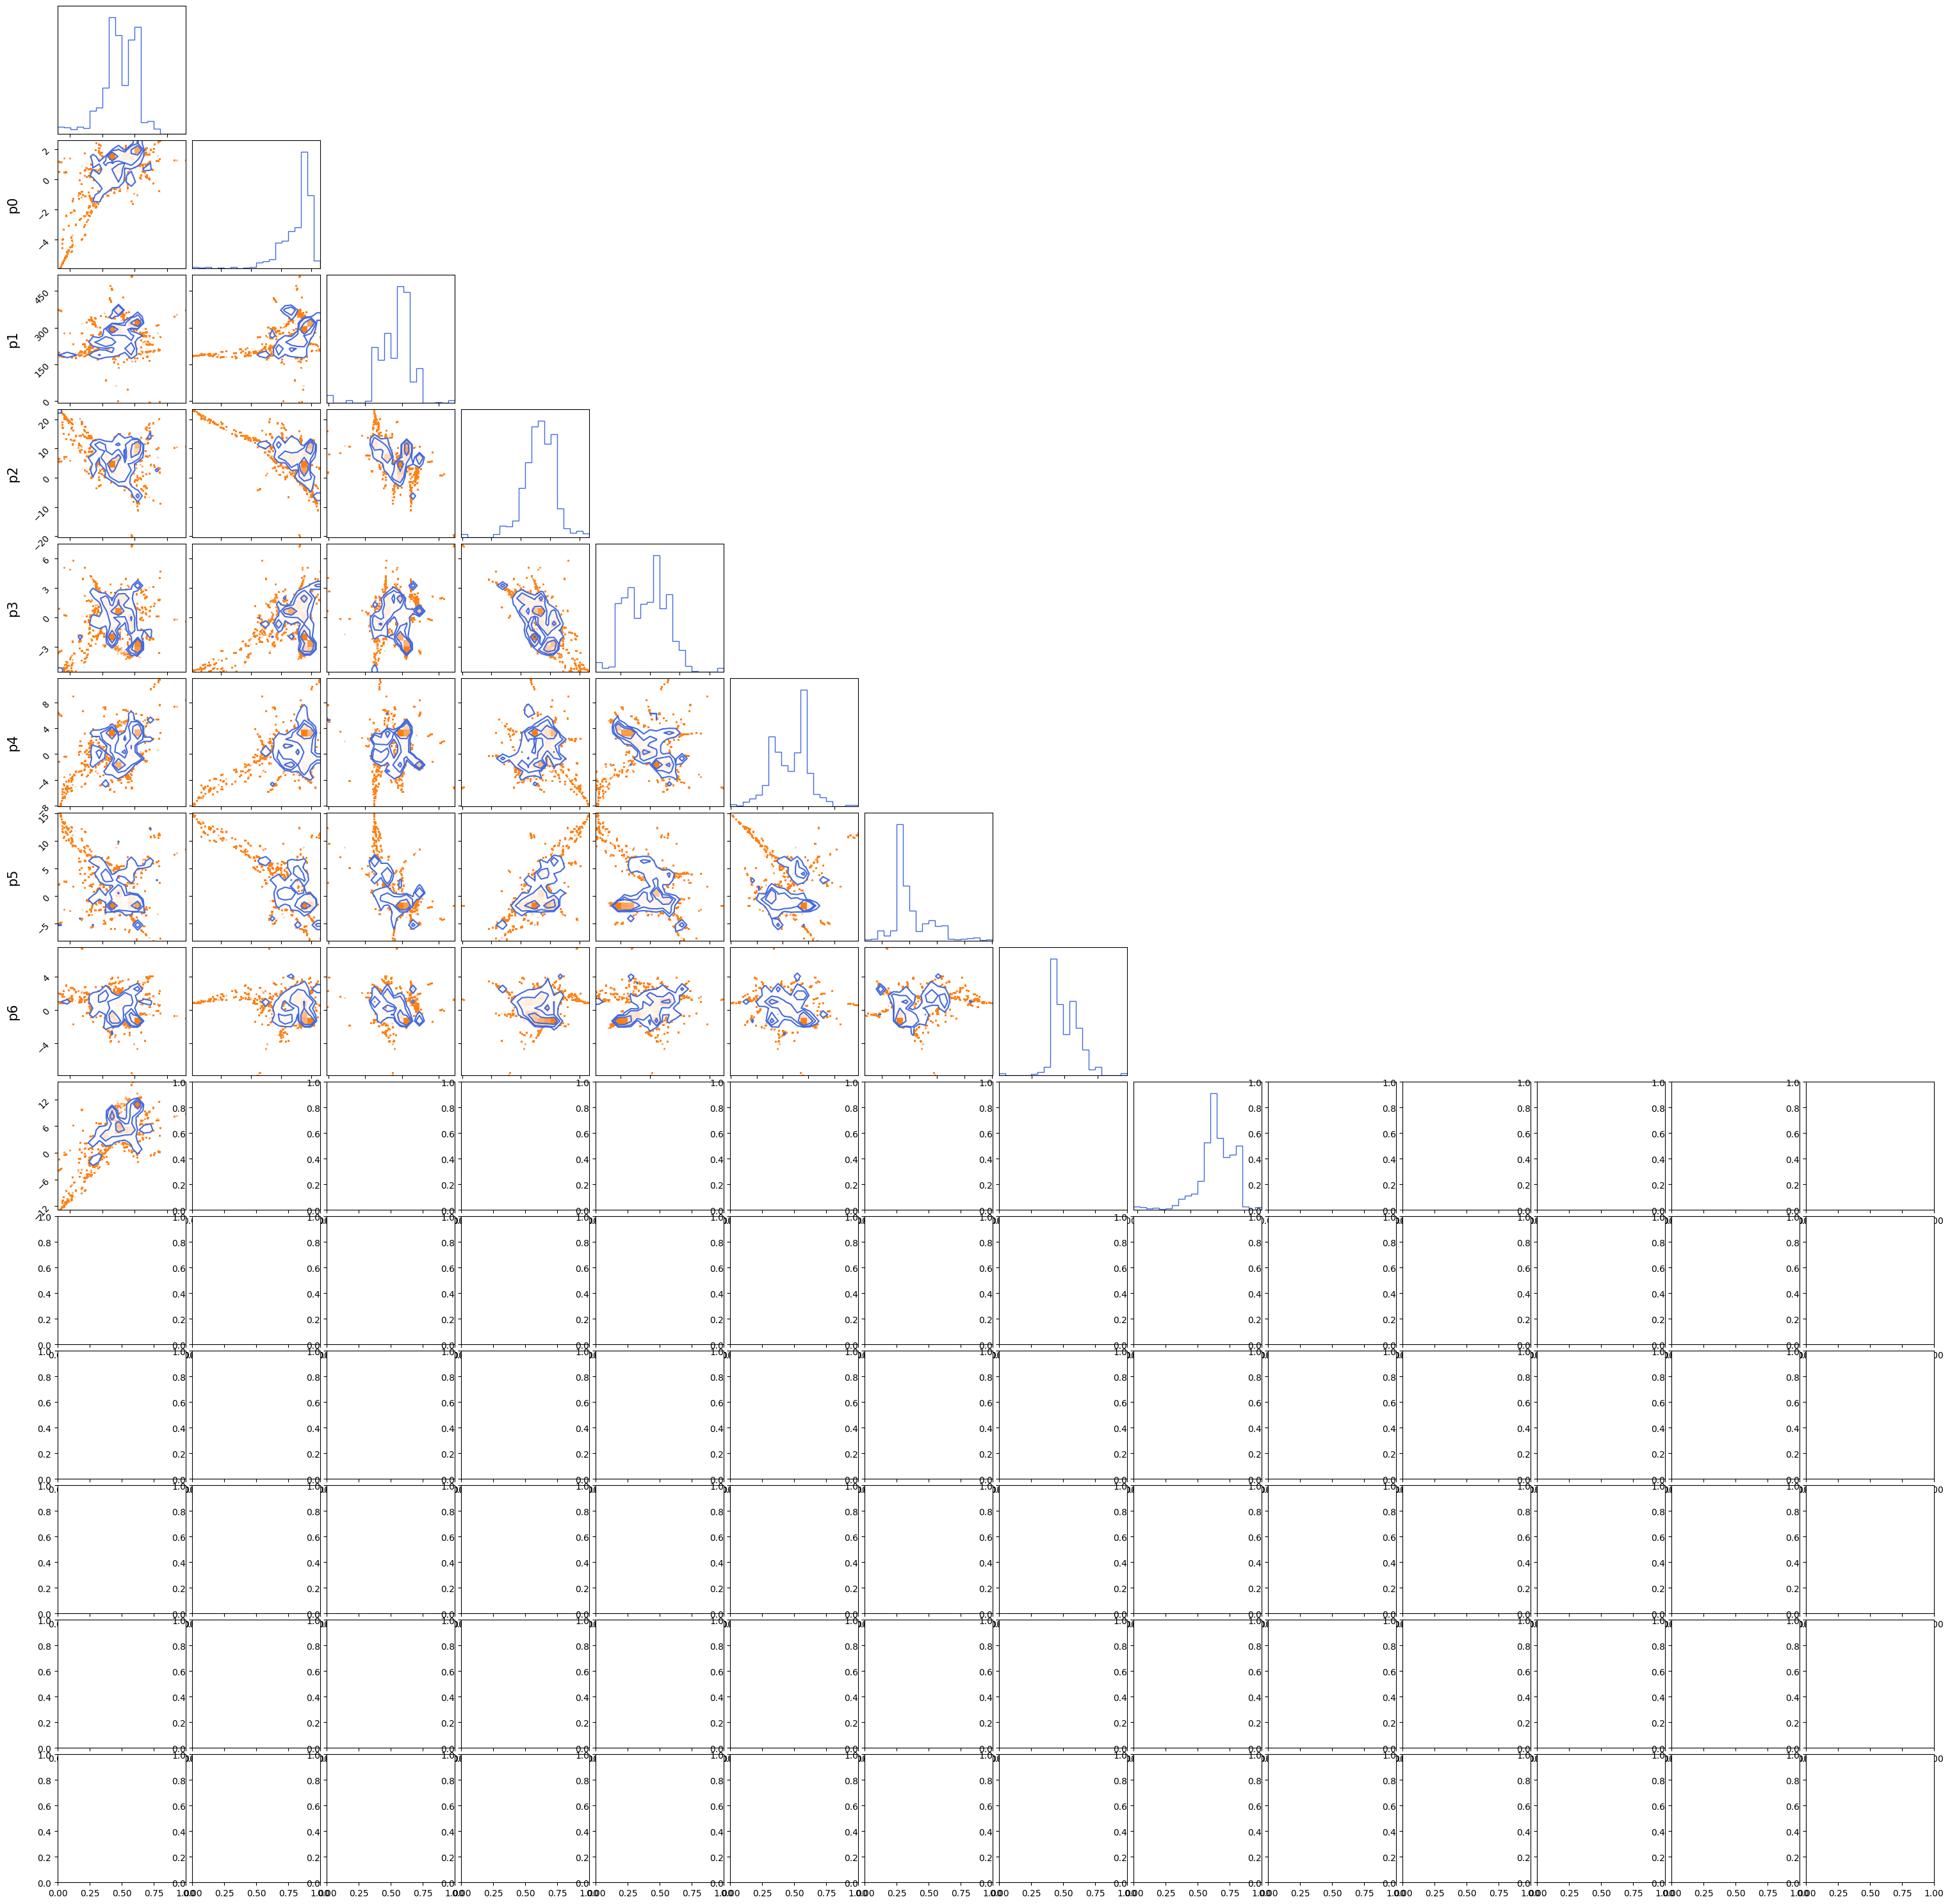

In [65]:
parameter_names = ["PA", "p0", "p1", "p2", "p3", "p4", "p5", "p6"]
#corner plot 
fig = corner.corner(samples, labels=parameter_names, truths=ip_params, color='C1',  # Change color of the contour and histograms
hist_kwargs={"color": "royalblue"},  # Set histogram color
label_kwargs={"fontsize":15}, #set label size
contour_kwargs={"colors": ["royalblue"]},  # Set contour color
truth_color="green" ) # Color for the true parameter values)
#plt.savefig('/Users/gopipatel/Desktop/MCMC_load.png', dpi=300)
plt.show()

#print("Expected Paramerters:",ip_params)
print("Best-fit parameters (Maximum Likelihood Estimate):", best_fit_params_rlc)

## Full RLC with Open as initials

In [104]:
########## Define the log-likelihood function
def log_likelihood(ip_params, params):
    
    PAo, gamma_Ao, PArlc, p0, p1, p2, p3, p4, p5, p6, PN, gamma_N, f, l = ip_params
    
    # Define the Expected TA values for open
    TA_exp_o = Compute_Tmeas_(PAo, gamma_Ao, PN, gamma_N, f, l) + np.random.normal(0,0.001,len(freq))  # Expected TA values
    TA_exp_o=np.array(TA_exp_o)

    # Define the Expected TA values for RLC
    TA_exp_rlc = Compute_Tmeas_RLC(PArlc, p0, p1, p2, p3, p4, p5, p6, PN, gamma_N, f, l) + np.random.normal(0,0.001,len(freq))  # Expected TA values
    TA_exp_rlc=np.array(TA_exp_rlc)

    PAo, gamma_Ao, PArlc, p0, p1, p2, p3, p4, p5, p6, PN, gamma_N, f, l = params
    
    # Compute model TA for open
    TA_model_o = Compute_Tmeas_(PAo, gamma_Ao, PN, gamma_N, f, l)
    TA_model_o=np.array(TA_model_o)

    # Compute model TA for open
    TA_model_rlc = Compute_Tmeas_RLC(PArlc, p0, p1, p2, p3, p4, p5, p6, PN, gamma_N, f, l)
    TA_model_rlc=np.array(TA_model_rlc)
    
    # Compute chi-squared for open
    s = 0.001  # Uncertainty
    chi2_o = np.sum([((TA_exp_o - TA_model_o)/s)** 2 ]) 

    # Compute chi-squared for RLC
    s = 0.001  # Uncertainty
    chi2_rlc = np.sum([((TA_exp_rlc - TA_model_rlc)/s)** 2 ]) 

    # Likelihood function
    Likelihood= -0.5*chi2_o-0.5*chi2_rlc-2*np.log(math.sqrt(2*np.pi)*s) 
    return Likelihood

########## Define the log-prior function
def log_prior(params,v):
    
    PAo, gamma_Ao, PArlc, p0, p1, p2, p3, p4, p5, p6, PN, gamma_N, f, l = params
    """
    # Check if params are within bounds
    if 0.0 < PA < 5 and 0.0 < gamma_A < 1.0 and 5.0 < PN < 100.0 and 0.0 < gamma_N < 1.0 and 0.05 < f < 0.9 and 0.1 < l < 1.0:
        return 0.0
    return -np.inf
    """
    for i in range(len(v)):
        gamma_A=np.polyval([p0, p1, p2, p3, p4, p5, p6],i)
        if not (-1 <= gamma_A <= 1):
            return -np.inf  # Reject sample
    
    return 0.0  # Uniform prior

######### Define the full log-probability function

def log_probability(ip_params,params,v):
    lp = log_prior(params,v)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(ip_params,params)

########### MCMC

def evolve_MCMC_Joint(ip_params, nsteps, initial_value,v):# Define parameter names
    parameter_names = ["PA", "gamma_A", "PA", "p0", "p1", "p2", "p3", "p4", "p5", "p6", "PN", "gamma_N", "f","l"]

    # Define bounds for parameters
    """
    min_values = [0.0, 0.0, 50.0, 0.0, 0.05,0.05]
    if type=='open' or type=='short':
        max_values= [5, 1, 150, 1,0.5, 13] 
    else:
        max_values = [350, 1, 150, 1, 0.5, 13] #maximum value of mass being scanned for load terminal
    """
    

    # Number of walkers and steps
    ndim = 14  # Number of parameters
    nwalkers = 200  # Number of MCMC walkers
    nsteps = nsteps  # Number of MCMC steps per walker
    
    # Initialize walkers around a random point in parameter space
    initial_value= np.array(initial_value)
    
    ## Starting positions for the walkers
    pos= initial_value[None,:] + initial_value*1e-1*np.random.randn(nwalkers, ndim) #initial_exact[None,:]*

    #Make sure all the positions are positive
    """
    for idim in range(ndim):
        ind_pos = pos[:,idim]<0
        pos[ind_pos,idim] = np.abs(pos[ind_pos,idim])
    """
    
    #pos= initial_exact+ 1e-1*np.array([[np.random.uniform(min_v, max_v) for min_v, max_v in zip(min_values, max_values)] for _ in range(nwalkers)]) 

    def wrap_log_probability(params):
        return log_probability(ip_params, params,v)
        
    ############ Set up the MCMC sampler
    sampler = emcee.EnsembleSampler(nwalkers, ndim, wrap_log_probability, threads=10)
    
    ############ Run MCMC
    print("Running MCMC...")
    sampler.run_mcmc(pos, nsteps, progress=True)
    
    ############ Extract the samples
    #samples = sampler.flatchain
    full_samples=sampler.get_chain()
    samples = sampler.get_chain(discard=500, flat=True)

    ######### Compute log-likelihoods for all samples
    log_likes = np.array([log_likelihood(ip_params, p) for p in samples])
    
    ######### Find the index of the maximum likelihood
    max_likelihood_index = np.argmax(log_likes)
    
    ########## Get the best-fit parameters
    best_fit_params = samples[max_likelihood_index].tolist()

    return full_samples,samples,best_fit_params

In [105]:
#PA=300
#s=0.01
v=[d[i][0] for i in range(len(d)-1)]
PA_o,gamma_Ao,PN,gamma_N,f,l=best_fit_params_o
PArlc, p0, p1, p2, p3, p4, p5, p6= best_fit_params_rlc
#kwargs={"PA":PA, "PN":PN,  "gamma_N":gamma_N, "f":f, "l":l, "s":s}
ip_params=[0, 1, 300, -6.33,  2.67, -4.56,  4.17, -2.186,  5.07,  4.73, 70, 0.3, 0.1, 1]
initials=[0.1, 0.97, 301, -6.1,  2.5, -4.3,  4.0, -2.06,  4.9,  4.57, 70.5, 0.29, 0.099, 0.98]

full_samples, samples, best_fit_params_joint= evolve_MCMC_Joint(ip_params=ip_params, nsteps=nsteps, initial_value=initials,v=v)

Running MCMC...


100%|██████████████████████████████████████| 3000/3000 [00:06<00:00, 489.33it/s]


KeyboardInterrupt: 

2025-04-23 15:42:46,111 - root - WARNING - Too few points to create valid contours
2025-04-23 15:42:46,222 - root - WARNING - Too few points to create valid contours
2025-04-23 15:42:46,291 - root - WARNING - Too few points to create valid contours
2025-04-23 15:42:46,393 - root - WARNING - Too few points to create valid contours
2025-04-23 15:42:46,461 - root - WARNING - Too few points to create valid contours
2025-04-23 15:42:46,525 - root - WARNING - Too few points to create valid contours
2025-04-23 15:42:46,626 - root - WARNING - Too few points to create valid contours
2025-04-23 15:42:46,692 - root - WARNING - Too few points to create valid contours
2025-04-23 15:42:46,759 - root - WARNING - Too few points to create valid contours
2025-04-23 15:42:46,820 - root - WARNING - Too few points to create valid contours
2025-04-23 15:42:46,918 - root - WARNING - Too few points to create valid contours
2025-04-23 15:42:46,979 - root - WARNING - Too few points to create valid contours
2025

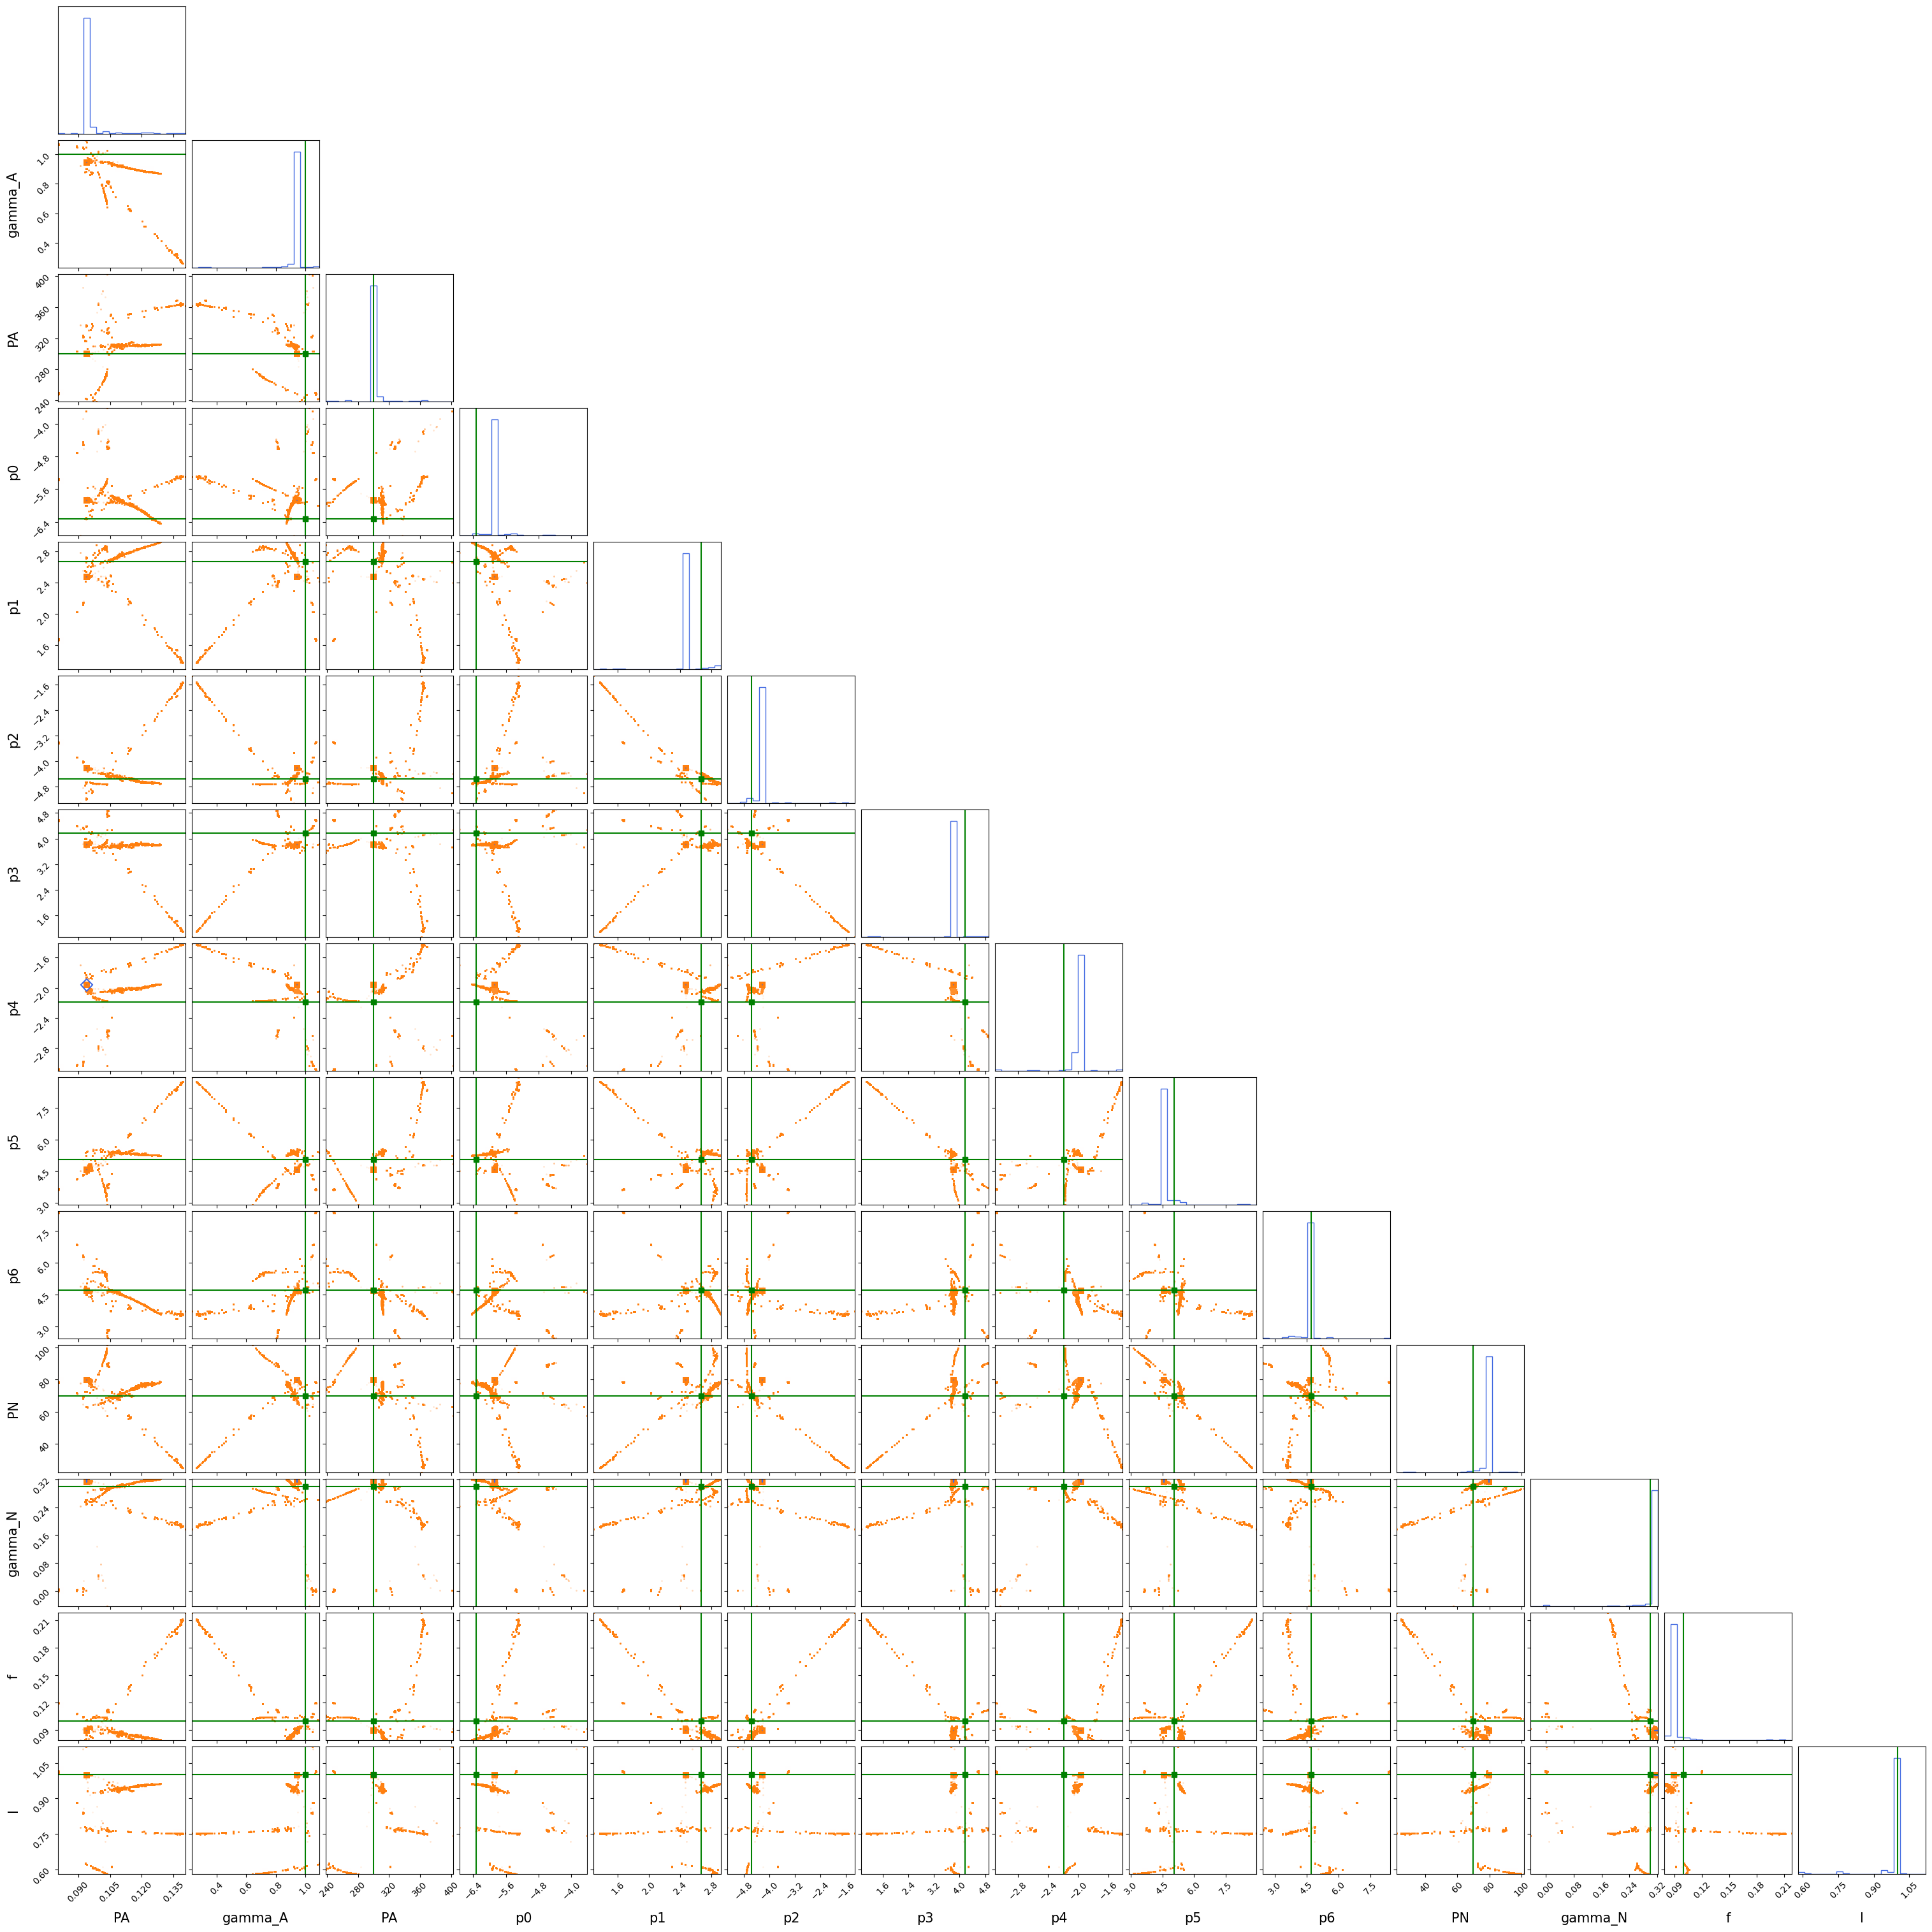

Best-fit parameters (Maximum Likelihood Estimate): [0.09358305438944582, 0.9459844210079845, 300.00954404659177, -5.848759259359305, 2.4598332012042574, -4.186166717966329, 3.8161924540424925, -1.9969916868948934, 4.5947110865421585, 4.7008405224259295, 80.7762236658497, 0.31710869445762546, 0.0916055255054138, 0.9999957421841802]


In [72]:
parameter_names = ["PA", "gamma_A", "PA", "p0", "p1", "p2", "p3", "p4", "p5", "p6", "PN", "gamma_N", "f","l"]
#corner plot 
fig = corner.corner(samples, labels=parameter_names, truths=ip_params, color='C1',  # Change color of the contour and histograms
hist_kwargs={"color": "royalblue"},  # Set histogram color
label_kwargs={"fontsize":15}, #set label size
contour_kwargs={"colors": ["royalblue"]},  # Set contour color
truth_color="green" ) # Color for the true parameter values)
#plt.savefig('/Users/gopipatel/Desktop/MCMC_load.png', dpi=300)
plt.show()

#print("Expected Paramerters:",ip_params)
print("Best-fit parameters (Maximum Likelihood Estimate):", best_fit_params_joint)

Text(0, 0.5, 'S11')

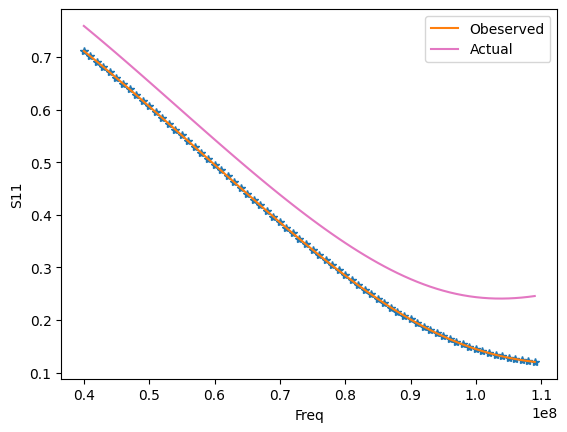

In [101]:
#Reconstructed S11

#Loading S11(RLC) and Frequency values
data = map(lambda x: [ x[0], x[1], x[2] ],
        np.loadtxt("/Users/gopipatel/Documents/RRI_VSP/saras3_S11_200mm_above_water.s1p", skiprows=5))
d=list(data) #List of the format [Frequency, Magnitude, Phase (in degrees)]
v=[d[i][0] for i in range(len(d)-1)]
df=pd.read_csv('/Users/gopipatel/Downloads/S11_for_freq.csv')
rlc = df[df.columns[1]].values.tolist()

po,p1,p2,p3,p4,p5,p6=[ -5.848759259359305, 2.4598332012042574, -4.186166717966329, 3.8161924540424925, -1.9969916868948934, 4.5947110865421585, 4.7008405224259295]
#[-6.274954869166671, 2.716009717976181, -4.6891133131425535, 4.149936149195398, -2.270563185191849, 4.867143968582065, 4.753308867794712]
#p6,p5,p4,p3,p2,p1,p0=
N=7
gamma_rlc=[]
for i in range(len(v)):
    
    gamma_value = (p0 *1e-48* v[i] ** (N - 1) + 
                   p1 *1e-39* v[i] ** (N - 2) + 
                   p2 *1e-31* v[i] ** (N - 3) + 
                   p3 *1e-23* v[i] ** (N - 4) + 
                   p4 *1e-15* v[i] ** (N - 5) + 
                   p5 *1e-08* v[i] ** (N - 6) + 
                   p6*1e-01)
    gamma_rlc.append(gamma_value) 

gamma_A=np.polyval([ -5.848759259359305*1e-48, 2.4598332012042574*1e-39, -4.186166717966329*1e-31, 3.8161924540424925*1e-23, -1.9969916868948934*1e-15, 4.5947110865421585*1e-08, 4.7008405224259295*1e-01],v)
plt.plot(v,gamma_A,"*")
plt.plot(v,gamma_rlc, label='Obeserved')
plt.plot(v,rlc,'tab:pink', label='Actual')
plt.legend()
plt.xlabel('Freq')
plt.ylabel('S11')

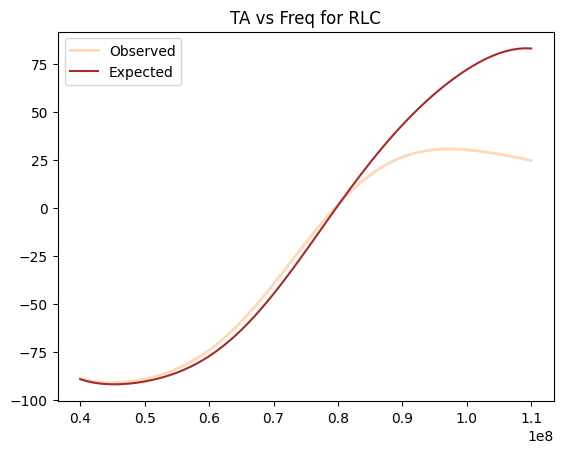

In [87]:
#PA, p0, p1, p2, p3, p4, p5, p6, PN, gamma_N, f, l = best_fit_params
PAo, gamma_Ao, PArlc, p0, p1, p2, p3, p4, p5, p6, PN, gamma_N, f, l= best_fit_params_joint
Ta=Compute_Tmeas_RLC(PArlc, p0, p1, p2, p3, p4, p5, p6, PN, gamma_N, f, l)
ip_params=[300,-6.33,  2.67, -4.56,  4.2, -2.2,  5.1,  4.7, 70, 0.3, 0.1, 1]
TA=Compute_Tmeas_RLC(*ip_params)
v=[d[i][0] for i in range(len(d))]
plt.plot(v,Ta,label='Observed', color='C1',alpha=0.3, lw=2)
plt.plot(v,TA,label='Expected', color='brown')
plt.legend()
plt.title('TA vs Freq for RLC')
plt.savefig('/Users/gopipatel/Desktop/Comparision_plot_2m.png', dpi=300)